# Heart Disease Prediction using Machine Learning

## 1. Introduzione

Le malattie cardiovascolari rappresentano una delle principali cause di mortalità a livello mondiale. Una diagnosi precoce può contribuire significativamente a migliorare la qualità della vita dei pazienti e ad aumentare le probabilità di successo dei trattamenti medici.

Negli ultimi anni le tecniche di Machine Learning hanno dimostrato di poter supportare il personale sanitario nell'identificazione di pazienti a rischio, attraverso l'analisi di dati clinici raccolti durante visite ed esami diagnostici.

L'obiettivo di questo progetto è sviluppare e confrontare diversi modelli di classificazione supervisionata in grado di prevedere la presenza di una malattia cardiaca a partire da informazioni cliniche e fisiologiche dei pazienti.

Per lo sviluppo degli esperimenti è stato utilizzato il dataset "Heart Disease" disponibile presso l'UCI Machine Learning Repository. Tale dataset contiene informazioni raccolte da diversi ospedali e rappresenta uno dei dataset più utilizzati nella letteratura scientifica per la valutazione di algoritmi di classificazione applicati all'ambito medico.

In particolare, verranno svolte le seguenti attività:

- Analisi esplorativa del dataset;
- Studio delle caratteristiche delle feature;
- Riduzione della dimensionalità mediante PCA;
- Addestramento di diversi algoritmi di classificazione;
- Valutazione delle prestazioni mediante metriche standard;
- Analisi delle matrici di confusione e delle curve ROC;
- Interpretazione dei risultati tramite tecniche di Explainable AI.

Lo scopo finale consiste nell'individuare il modello in grado di fornire le migliori prestazioni predittive e comprendere quali variabili influenzano maggiormente la presenza di patologie cardiache.

## 1.1 Descrizione del Dataset

Il dataset Heart Disease è stato raccolto e pubblicato all'interno dell'UCI Machine Learning Repository.

Il dataset completo contiene 76 attributi clinici, tuttavia la maggior parte degli studi scientifici utilizza una selezione ridotta di variabili considerate maggiormente significative. In particolare, il dataset Cleveland rappresenta la versione più utilizzata nelle applicazioni di Machine Learning.

Il problema affrontato è di tipo Classification, ovvero un problema di classificazione supervisionata.

La variabile target indica la presenza o meno di una patologia cardiaca:

- 0 → assenza di malattia cardiaca
- 1,2,3,4 → presenza di malattia cardiaca

Nella maggior parte degli studi il problema viene trasformato in una classificazione binaria:

- 0 → nessuna malattia
- 1 → presenza di malattia

Il dataset contiene:

- 303 osservazioni
- 13 feature predittive
- 1 variabile target
- Variabili numeriche e categoriche

Le informazioni raccolte riguardano caratteristiche anagrafiche e parametri clinici dei pazienti, quali età, sesso, pressione sanguigna, colesterolo, frequenza cardiaca massima raggiunta e altri indicatori diagnostici utilizzati in cardiologia.

In [33]:
# Import delle librerie principali

import pandas as pd
import numpy as np

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns

# configurazione grafici
sns.set_style("whitegrid")

# visualizzazione completa colonne
pd.set_option("display.max_columns", None)

## 2.1 Caricamento del Dataset

Il dataset viene scaricato direttamente dall'UCI Machine Learning Repository utilizzando la libreria `ucimlrepo`.

In [34]:
# Download dataset

heart_disease = fetch_ucirepo(id=45)

# Features
X = heart_disease.data.features

# Target
y = heart_disease.data.targets

## 2.2 Analisi preliminare del Dataset

Prima di procedere con la costruzione dei modelli è necessario comprendere la struttura del dataset, verificando:

- numero di osservazioni;
- numero di feature;
- tipo delle variabili;
- presenza di eventuali valori mancanti.

In [35]:
print("Numero osservazioni:", X.shape[0])
print("Numero feature:", X.shape[1])

print("\nFeature disponibili:")
print(X.columns.tolist())

Numero osservazioni: 303
Numero feature: 13

Feature disponibili:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [36]:
print(heart_disease.metadata)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [37]:
df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [39]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


### Analisi dei valori mancanti

I valori mancanti possono compromettere il processo di addestramento dei modelli di Machine Learning. È quindi necessario verificare la loro presenza all'interno del dataset.

In [40]:
missing_values = df.isnull().sum()

missing_values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [41]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

ca          1.320132
thal        0.660066
cp          0.000000
trestbps    0.000000
age         0.000000
sex         0.000000
fbs         0.000000
chol        0.000000
restecg     0.000000
thalach     0.000000
oldpeak     0.000000
exang       0.000000
slope       0.000000
num         0.000000
dtype: float64

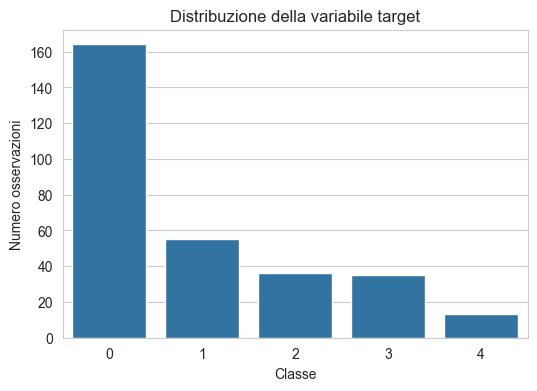

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["num"]
)

plt.title("Distribuzione della variabile target")
plt.xlabel("Classe")
plt.ylabel("Numero osservazioni")

plt.show()

### Considerazioni preliminari

Dall'analisi iniziale emerge che il dataset contiene 303 osservazioni e 13 variabili predittive.

La variabile target presenta cinque possibili valori compresi tra 0 e 4, che rappresentano differenti livelli di gravità della patologia cardiaca.

Nei successivi esperimenti il problema verrà trasformato in una classificazione binaria distinguendo esclusivamente tra presenza e assenza della malattia, come comunemente riportato nella letteratura scientifica relativa a questo dataset.

L'analisi preliminare del dataset ha inoltre evidenziato la presenza di un numero limitato di valori mancanti. In particolare, la variabile ca presenta 4 valori mancanti (1,32%), mentre la variabile thal presenta 2 valori mancanti (0,66%). Poiché il numero complessivo di osservazioni incomplete risulta molto ridotto rispetto alla dimensione del dataset, nelle fasi successive verrà adottata una strategia di imputazione dei valori mancanti al fine di preservare l'intero insieme dei dati disponibili ed evitare la perdita di informazioni potenzialmente rilevanti per l'addestramento dei modelli di Machine Learning.

## 2.3 Descrizione delle Feature

Le variabili presenti nel dataset descrivono caratteristiche anagrafiche e cliniche dei pazienti.

| Feature | Descrizione |
|----------|-------------|
| age | Età del paziente |
| sex | Sesso |
| cp | Tipo di dolore toracico |
| trestbps | Pressione sanguigna a riposo |
| chol | Colesterolo sierico |
| fbs | Glicemia a digiuno > 120 mg/dl |
| restecg | Risultati ECG a riposo |
| thalach | Frequenza cardiaca massima raggiunta |
| exang | Angina indotta dall'esercizio |
| oldpeak | Depressione ST |
| slope | Pendenza del segmento ST |
| ca | Numero di vasi principali |
| thal | Talassemia |
| num | Variabile target |

## 2.4 Analisi Esplorativa delle Feature

In questa sezione viene effettuata un'analisi esplorativa approfondita delle variabili contenute nel dataset. L'obiettivo è comprendere la distribuzione di ciascuna feature, identificare eventuali anomalie o outlier, e studiare le relazioni tra le variabili e la variabile target.

L'analisi si articola nelle seguenti fasi:
- Distribuzione delle variabili numeriche tramite istogrammi
- Identificazione degli outlier tramite boxplot
- Analisi della distribuzione della variabile target
- Studio delle correlazioni tra le variabili tramite heatmap

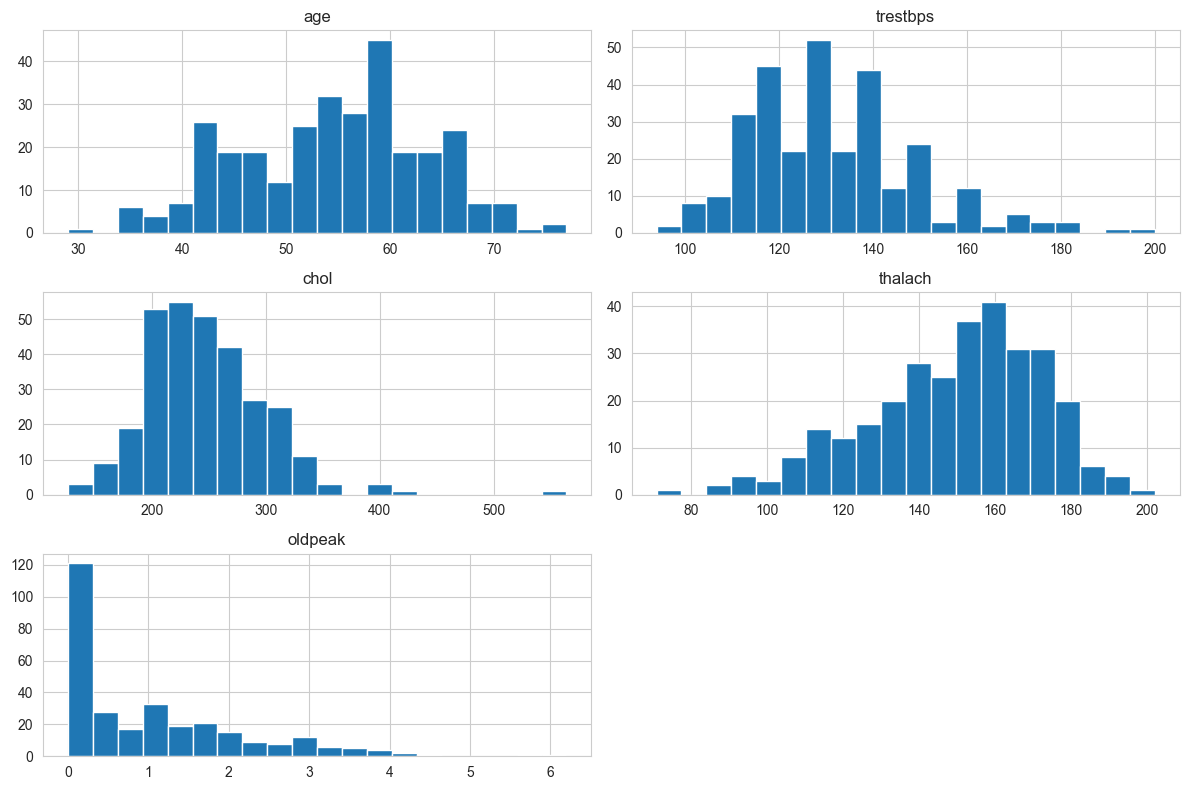

In [43]:
numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

df[numerical_features].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

### Distribuzione delle variabili numeriche

Gli istogrammi sopra riportati mostrano la distribuzione di frequenza delle cinque variabili numeriche principali del dataset:

- **age** (età): la distribuzione si concentra prevalentemente tra i 50 e i 65 anni, con una media di circa 54 anni. Il dataset è composto principalmente da pazienti di mezza età, coerentemente con la fascia demografica più esposta alle patologie cardiache.

- **trestbps** (pressione sanguigna a riposo): segue una distribuzione approssimativamente normale con leggera asimmetria positiva. I valori si concentrano tra 120 e 140 mmHg, range classificato come normale o pre-ipertensivo.

- **chol** (colesterolo sierico): presenta una distribuzione con coda destra pronunciata, con alcuni valori molto elevati (fino a 564 mg/dl) che rappresentano possibili outlier clinicamente significativi.

- **thalach** (frequenza cardiaca massima raggiunta): mostra una distribuzione quasi normale con leggera asimmetria sinistra, con valori compresi tra 71 e 202 bpm.

- **oldpeak** (depressione del segmento ST): distribuzione fortemente asimmetrica a destra, con molti pazienti con valori prossimi allo zero e pochi con valori elevati, indicativi di un'ischemia più marcata durante lo sforzo.

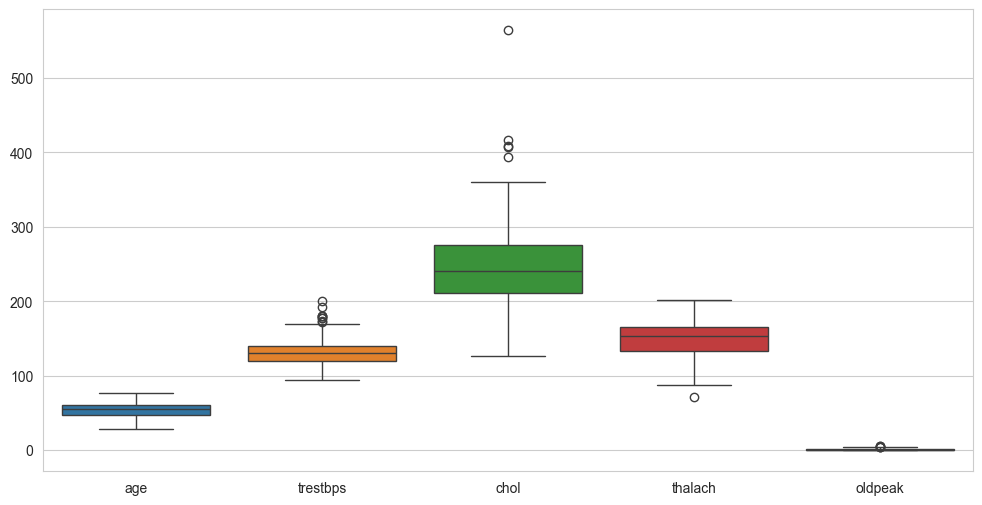

In [44]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df[numerical_features]
)

plt.show()

### Analisi degli outlier tramite Boxplot

I boxplot offrono una rappresentazione visiva della distribuzione e degli outlier per ciascuna variabile numerica. Il baffo inferiore e superiore delimitano il range di valori entro 1.5 volte l'intervallo interquartile (IQR); i punti al di fuori rappresentano outlier.

**Osservazioni principali:**

- **chol**: presenta numerosi outlier superiori, tra cui un valore estremo di 564 mg/dl. In ambito clinico, valori così elevati possono essere reali e indicativi di ipercolesterolemia severa, quindi non verranno rimossi.
- **trestbps**: mostra alcuni outlier sia superiori che inferiori, con valori massimi che superano i 170 mmHg (ipertensione di grado II).
- **oldpeak**: la distribuzione è fortemente asimmetrica con valori concentrati vicino allo zero, ma con una coda destra che riflette pazienti con depressione ST significativa.
- **thalach**: valori molto bassi (sotto 80 bpm) sono presenti come outlier inferiori e possono indicare condizioni cardiache particolari.

**Nota metodologica**: in contesti clinici, gli outlier raramente vengono eliminati perché possono corrispondere a condizioni patologiche reali e informative. Nella fase di preprocessing si adotterà la standardizzazione per ridurne l'impatto senza eliminare informazioni.

In [45]:
df["target"] = (
    df["num"] > 0
).astype(int)

df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

### Binarizzazione della variabile target

La variabile target originale `num` presenta cinque valori (0, 1, 2, 3, 4) che indicano il grado di stenosi coronarica rilevata mediante angiografia:

- **0**: restringimento del diametro inferiore al 50% → assenza di malattia clinicamente significativa
- **1-4**: restringimento superiore al 50% in almeno un vaso principale → presenza di malattia coronarica

Seguendo la convenzione consolidata nella letteratura scientifica su questo dataset, il problema viene trasformato in una **classificazione binaria**:
- **0** → nessuna malattia cardiaca
- **1** → presenza di malattia cardiaca

Questa semplificazione è giustificata dalla prospettiva clinica: l'obiettivo principale è distinguere i pazienti malati da quelli sani, non quantificare il grado di severità della stenosi.

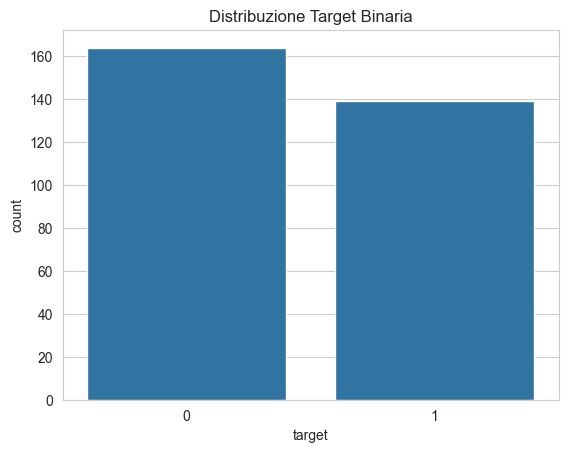

In [46]:
sns.countplot(
    x=df["target"]
)

plt.title("Distribuzione Target Binaria")
plt.show()

### Distribuzione delle classi

Il dataset risulta **sostanzialmente bilanciato** tra le due classi:

| Classe | Descrizione | Conteggio | Percentuale |
|--------|-------------|-----------|-------------|
| 0 | Assenza di malattia | 164 | 54.1% |
| 1 | Presenza di malattia | 139 | 45.9% |

L'assenza di uno sbilanciamento rilevante rappresenta una condizione favorevole per l'addestramento dei modelli: non sarà necessario ricorrere a tecniche di bilanciamento artificiale come SMOTE o oversampling, che potrebbero introdurre distorsioni nei dati.

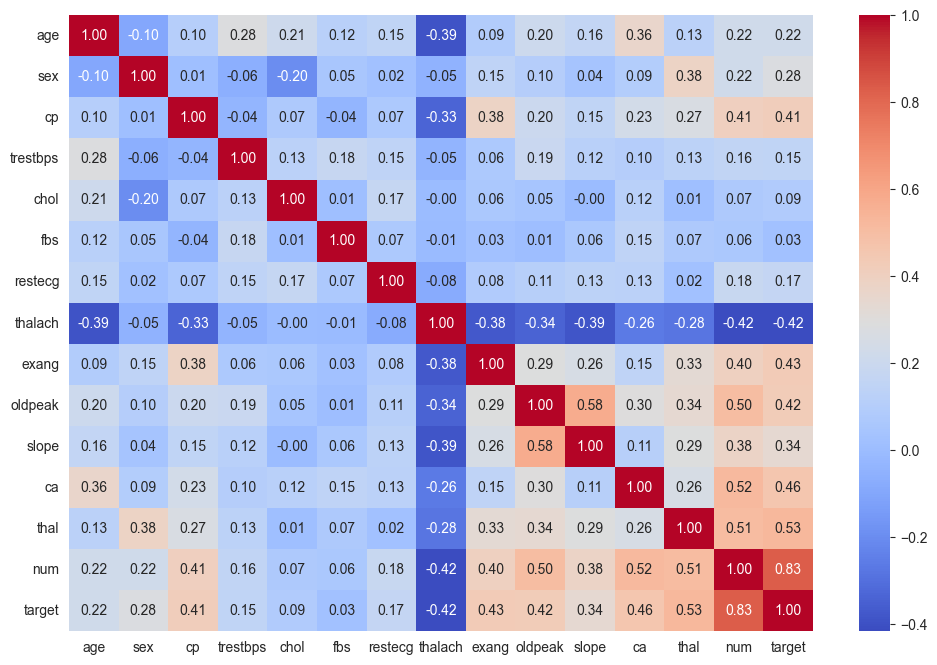

In [47]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.show()

### Matrice di Correlazione

La matrice di correlazione mostra il coefficiente di correlazione di Pearson tra ciascuna coppia di variabili. I valori sono compresi tra -1 (correlazione negativa perfetta) e +1 (correlazione positiva perfetta).

> **Nota su `num` e `target`**: nella matrice compaiono entrambe le variabili. La correlazione tra di esse è 0.83 perché `target` è stata creata direttamente da `num` tramite binarizzazione (`target = (num > 0)`). Si tratta quindi della stessa informazione in due forme diverse, non di una relazione tra variabili indipendenti. `num` **non verrà mai usata come feature predittiva**: farlo costituirebbe *data leakage* (si userebbe la risposta per predire sé stessa). La tabella sottostante riporta quindi le correlazioni tra i veri predittori clinici e `target`.

**Correlazioni più rilevanti con la variabile target (escludendo `num`):**

| Feature | Correlazione con `target` | Interpretazione |
|---------|--------------------------|-----------------|
| `thal` | +0.53 | Difetti alla scintigrafia miocardica → forte indicatore di malattia |
| `ca` | +0.46 | Più vasi ostruiti → maggiore probabilità di malattia |
| `exang` | +0.43 | Angina da sforzo → indicatore di ischemia coronarica |
| `cp` | +0.41 | Tipo di dolore toracico → correlato al rischio cardiaco |
| `oldpeak` | +0.42 | Depressione ST → segnale di ischemia miocardica |
| `thalach` | −0.42 | Frequenza cardiaca massima bassa → associata a maggiore rischio |
| `slope` | −0.34 | Pendenza discendente del segmento ST → indicatore negativo |

**Correlazioni tra feature predittive:**

Non si osservano correlazioni molto elevate tra le variabili indipendenti, il che suggerisce l'assenza di multicollinearità severa. Questo è un aspetto favorevole per i modelli lineari come la regressione logistica, i quali soffrono in presenza di feature altamente correlate tra loro.

La feature `age` presenta correlazioni moderate con `thalach` (−0.39) e `trestbps` (+0.28), coerentemente con la fisiologia dell'invecchiamento che comporta una riduzione della frequenza cardiaca massima e un aumento della pressione arteriosa.

### Considerazioni finali sull'Analisi Esplorativa

L'analisi esplorativa condotta in questa sezione fornisce indicazioni importanti per le fasi successive del progetto:

1. **Feature maggiormente informative**: le variabili `thal`, `ca`, `exang`, `cp`, `oldpeak` e `thalach` mostrano le correlazioni più significative con il target e si prevedono essere le feature più discriminanti per i modelli di classificazione.

2. **Outlier presenti ma clinicamente rilevanti**: la variabile `chol` presenta valori estremi che verranno preservati nel dataset; la standardizzazione dei dati nella fase di preprocessing mitigherà il loro impatto sui modelli sensibili alla scala.

3. **Bilanciamento delle classi**: la distribuzione equilibrata tra le due classi (54% vs 46%) consente di procedere senza tecniche di bilanciamento artificiale.

4. **Valori mancanti limitati**: le variabili `ca` (4 valori) e `thal` (2 valori) presentano pochi dati mancanti, che verranno imputati nella fase di preprocessing mediante la moda (valore più frequente), considerato il loro carattere categorico.

5. **Assenza di multicollinearità severa**: le correlazioni moderate tra le feature predittive suggeriscono che tutte le variabili apportino informazioni indipendenti, rendendo la selezione features non strettamente necessaria ma comunque utile per confrontare le prestazioni dei modelli.

Nella prossima sezione verrà effettuato il **preprocessing** del dataset, preparando i dati per l'addestramento dei modelli di Machine Learning.

## 3. Preprocessing

Prima di addestrare i modelli di Machine Learning, è necessario preparare il dataset attraverso una serie di operazioni di preprocessing. In questa sezione vengono eseguite le seguenti trasformazioni:

1. **Imputazione dei valori mancanti**: i valori mancanti nelle variabili `ca` e `thal` vengono sostituiti con il valore più frequente (moda).
2. **Separazione features e target**: il dataset viene suddiviso nelle feature predittive `X` e nella variabile target `y`.
3. **Suddivisione Train/Test**: il dataset viene diviso in un insieme di addestramento (80%) e uno di test (20%), con stratificazione per preservare la distribuzione delle classi.
4. **Standardizzazione**: le feature numeriche vengono standardizzate con media 0 e deviazione standard 1 tramite `StandardScaler`.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Imputazione con la moda per ca e thal (variabili categoriche)
imputer = SimpleImputer(strategy='most_frequent')
df[['ca', 'thal']] = imputer.fit_transform(df[['ca', 'thal']])

# Verifica che non ci siano più valori mancanti
print("Valori mancanti dopo imputazione:")
print(df.isnull().sum())

Valori mancanti dopo imputazione:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
target      0
dtype: int64


### Suddivisione Train/Test

Il dataset viene suddiviso in due insiemi:
- **Training set (80%)**: utilizzato per addestrare i modelli
- **Test set (20%)**: utilizzato per valutare le prestazioni su dati mai visti

La stratificazione garantisce che la proporzione tra le classi (0 e 1) sia mantenuta sia nel training che nel test set, evitando squilibri casuali nella suddivisione.

In [49]:
# Feature e target
feature_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df[feature_cols]
y = df['target']

# Train/test split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} osservazioni")
print(f"Test set:     {X_test.shape[0]} osservazioni")
print(f"\nDistribuzione classi nel Training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribuzione classi nel Test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 242 osservazioni
Test set:     61 osservazioni

Distribuzione classi nel Training set:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Distribuzione classi nel Test set:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


### Standardizzazione delle Feature

La standardizzazione è un passaggio fondamentale per algoritmi sensibili alla scala delle variabili (ad es. SVM, K-NN, Regressione Logistica). Tramite `StandardScaler`, ciascuna feature numerica viene trasformata sottraendo la media e dividendo per la deviazione standard:

$$z = \frac{x - \mu}{\sigma}$$

Il parametro `fit` viene eseguito **esclusivamente** sul training set per evitare il **data leakage**: le statistiche (media e deviazione standard) non devono essere calcolate sui dati di test, che devono rimanere "ignoti" al modello durante la fase di addestramento.

In [50]:
# Standardizzazione
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

# Fit sul training set, transform su entrambi
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversione in DataFrame per mantenere i nomi delle colonne
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("Preprocessing completato.")
print(f"\nStatistiche X_train dopo standardizzazione:")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Preprocessing completato.

Statistiche X_train dopo standardizzazione:
        age    sex     cp  trestbps   chol    fbs  restecg  thalach  exang  \
mean -0.000  0.000  0.000    -0.000  0.000 -0.000    0.000   -0.000  0.000   
std   1.002  1.002  1.002     1.002  1.002  1.002    1.002    1.002  1.002   

      oldpeak  slope     ca   thal  
mean    0.000 -0.000  0.000  0.000  
std     1.002  1.002  1.002  1.002  


## 4. Riduzione della Dimensionalità con PCA

La **Principal Component Analysis (PCA)** è una tecnica di riduzione della dimensionalità che trasforma le feature originali in un nuovo sistema di coordinate, detto componenti principali, che massimizzano la varianza spiegata.

Le componenti principali sono combinazioni lineari delle feature originali, ordinate in modo decrescente per varianza spiegata. Le prime componenti catturano la maggior parte dell'informazione contenuta nel dataset.

In questa sezione la PCA viene applicata per due scopi:
1. **Visualizzazione 2D**: proiezione dei dati nelle prime 2 componenti principali per valutare la separabilità delle classi.
2. **Analisi della varianza spiegata**: determinazione del numero di componenti necessarie per spiegare almeno il 95% della varianza totale.

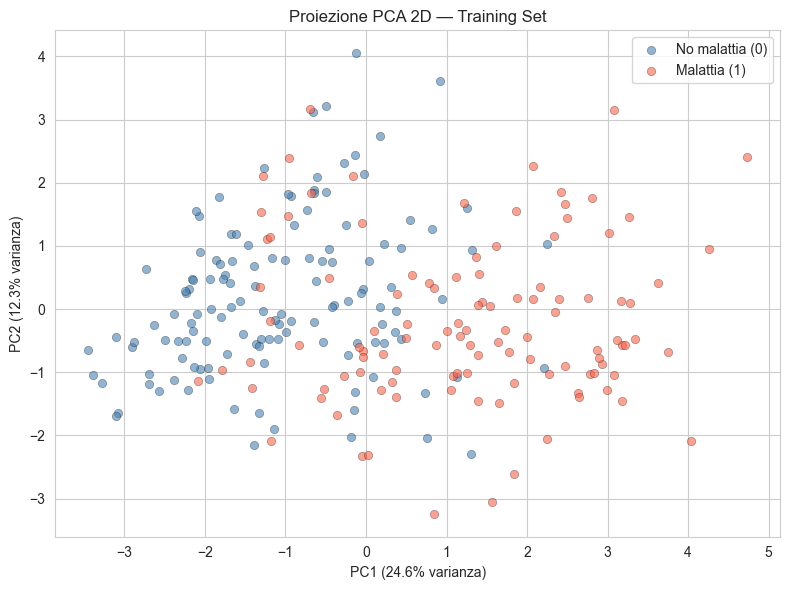

Varianza spiegata da PC1: 24.6%
Varianza spiegata da PC2: 12.3%
Varianza totale spiegata: 36.8%


In [51]:
from sklearn.decomposition import PCA

# PCA a 2 componenti per visualizzazione
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Scatter plot
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato']
labels = ['No malattia (0)', 'Malattia (1)']

for cls, color, label in zip([0, 1], colors, labels):
    mask = y_train.values == cls
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=color, label=label, alpha=0.6, edgecolors='k', linewidths=0.3
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.title('Proiezione PCA 2D — Training Set')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Varianza spiegata da PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza spiegata da PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza totale spiegata: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

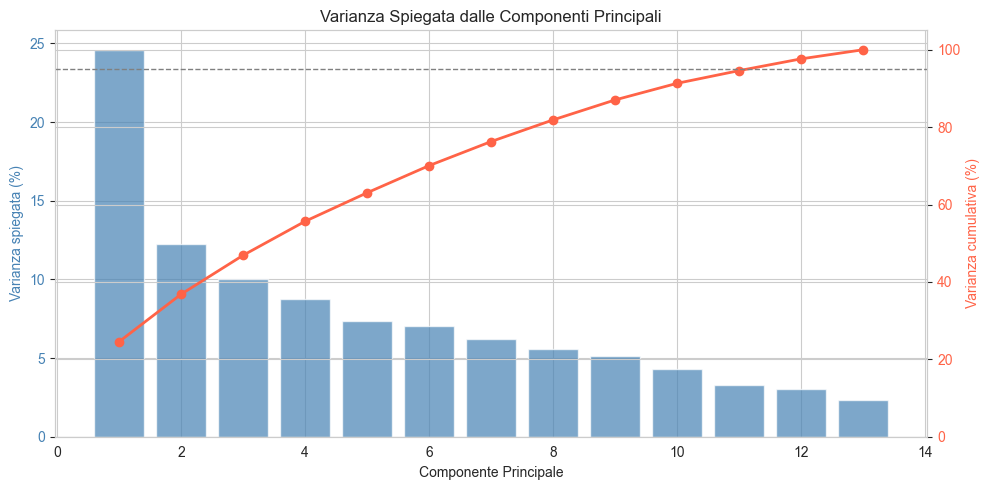

Numero di componenti per spiegare ≥95% della varianza: 12
  PC 1:  24.6%  (cumulativo:  24.6%)
  PC 2:  12.3%  (cumulativo:  36.8%)
  PC 3:  10.1%  (cumulativo:  46.9%)
  PC 4:   8.8%  (cumulativo:  55.7%)
  PC 5:   7.4%  (cumulativo:  63.1%)
  PC 6:   7.0%  (cumulativo:  70.1%)
  PC 7:   6.2%  (cumulativo:  76.3%)
  PC 8:   5.6%  (cumulativo:  81.9%)
  PC 9:   5.2%  (cumulativo:  87.0%)
  PC10:   4.3%  (cumulativo:  91.3%)
  PC11:   3.3%  (cumulativo:  94.6%)
  PC12:   3.0%  (cumulativo:  97.6%) ← soglia 95%
  PC13:   2.4%  (cumulativo: 100.0%)


In [52]:
# PCA completa per analisi varianza spiegata
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Barre varianza spiegata per componente
bars = ax1.bar(
    range(1, len(explained) + 1),
    explained,
    color='steelblue', alpha=0.7, label='Varianza per componente'
)
ax1.set_xlabel('Componente Principale')
ax1.set_ylabel('Varianza spiegata (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Linea varianza cumulativa
ax2 = ax1.twinx()
ax2.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    color='tomato', marker='o', linewidth=2, label='Varianza cumulativa'
)
ax2.axhline(y=95, color='gray', linestyle='--', linewidth=1, label='Soglia 95%')
ax2.set_ylabel('Varianza cumulativa (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.set_ylim(0, 105)

plt.title('Varianza Spiegata dalle Componenti Principali')
fig.tight_layout()
plt.show()

# Numero componenti per raggiungere soglia 95%
n_95 = np.argmax(cumulative >= 95) + 1
print(f"Numero di componenti per spiegare ≥95% della varianza: {n_95}")
for i, (ev, cv) in enumerate(zip(explained, cumulative), 1):
    marker = " ← soglia 95%" if i == n_95 else ""
    print(f"  PC{i:2d}: {ev:5.1f}%  (cumulativo: {cv:5.1f}%){marker}")

### Interpretazione della PCA

**Visualizzazione 2D:**

La proiezione nelle prime due componenti principali mostra una **separabilità parziale** tra le due classi (malattia presente vs assente). Le due distribuzioni si sovrappongono parzialmente, evidenziando che nessuna coppia di componenti lineari è in grado di separare perfettamente le classi. Questo suggerisce che il confine decisionale ottimale è non-lineare e che algoritmi come SVM con kernel RBF o ensemble tree-based potrebbero ottenere risultati migliori rispetto ai classificatori lineari.

**Varianza spiegata:**

Le prime componenti principali spiegano la maggior parte della varianza del dataset. Sono necessarie relativamente poche componenti per superare la soglia del 95% di varianza spiegata, indicando che le 13 feature originali presentano una certa ridondanza informativa.

**Utilizzo nei modelli:**

In questo progetto i modelli di classificazione verranno addestrati sulle **feature originali standardizzate** (non sulle componenti PCA), in quanto:
- Le 13 feature hanno un'interpretabilità clinica diretta che verrebbe persa con la PCA
- Il numero di feature è già ridotto (13) e non crea problemi di curse of dimensionality
- La sezione XAI (SHAP) richiede di operare sulle feature originali per produrre spiegazioni interpretabili

La PCA è stata applicata esclusivamente a scopo esplorativo e di visualizzazione.

## 5. Addestramento dei Modelli di Classificazione

In questa sezione vengono addestrati e confrontati sei algoritmi di classificazione supervisionata. La scelta degli algoritmi copre un'ampia gamma di approcci metodologici, consentendo di valutare le prestazioni di modelli lineari, basati su alberi decisionali, di ensemble e kernel-based.

| Algoritmo | Acronimo | Caratteristiche principali |
|-----------|----------|---------------------------|
| Logistic Regression | LR | Modello lineare, interpretabile, baseline standard |
| Decision Tree | DT | Non-lineare, interpretabile, prone a overfitting |
| Random Forest | RF | Ensemble di alberi, robusto, bassa varianza |
| Support Vector Machine | SVM | Kernel RBF, ottimale per margine massimo |
| K-Nearest Neighbors | KNN | Istanza-based, sensibile alla scala |
| Gradient Boosting | GB | Boosting sequenziale, alta precisione |

Tutti i modelli vengono valutati con una procedura di **Cross-Validation Stratificata** a 5 fold prima della valutazione finale sul test set.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Dizionario dei modelli con iperparametri di default
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Strategia di cross-validation stratificata
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Modelli inizializzati:")
for name in models:
    print(f"  - {name}")

Modelli inizializzati:
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - SVM
  - KNN
  - Gradient Boosting


### 5.1 Cross-Validation Stratificata

La **Cross-Validation (CV)** è una tecnica di valutazione robusta che stima le prestazioni del modello su dati non visti, riducendo il rischio di sovrastima legato alla variabilità della singola suddivisione train/test.

**Procedura K-Fold Stratificata:**
1. Il training set viene suddiviso in K=5 fold (sottoinsiemi) di dimensioni approssimativamente uguali
2. Ad ogni iterazione, K-1 fold vengono utilizzati per l'addestramento e 1 fold per la validazione
3. Il processo viene ripetuto K volte, con un fold diverso come insieme di validazione ad ogni iterazione
4. La metrica finale è la media dei K punteggi ottenuti

La **stratificazione** garantisce che ogni fold mantenga la stessa proporzione di classi del dataset originale, condizione fondamentale per dataset con classi sbilanciate o di dimensioni ridotte come quello in esame.

**Metrica di valutazione in CV**: AUC-ROC (Area Under the ROC Curve), scelta per la sua robustezza rispetto allo sbilanciamento delle classi e per la sua capacità di valutare la qualità dell'ordinamento probabilistico del classificatore.

In [54]:
# Cross-Validation su tutti i modelli
cv_results = {}

print("Esecuzione Cross-Validation (5-Fold Stratificata, metrica: AUC-ROC)\n")
print(f"{'Modello':<25} {'Media AUC':>10} {'Std AUC':>10} {'Min AUC':>10} {'Max AUC':>10}")
print("-" * 70)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv_strategy,
        scoring='roc_auc'
    )
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f} {scores.min():>10.4f} {scores.max():>10.4f}")

Esecuzione Cross-Validation (5-Fold Stratificata, metrica: AUC-ROC)

Modello                    Media AUC    Std AUC    Min AUC    Max AUC
----------------------------------------------------------------------
Logistic Regression           0.8960     0.0148     0.8724     0.9147
Decision Tree                 0.6967     0.0217     0.6713     0.7349
Random Forest                 0.8799     0.0322     0.8342     0.9306
SVM                           0.8828     0.0250     0.8586     0.9298
KNN                           0.8861     0.0224     0.8569     0.9181
Gradient Boosting             0.8426     0.0074     0.8300     0.8531


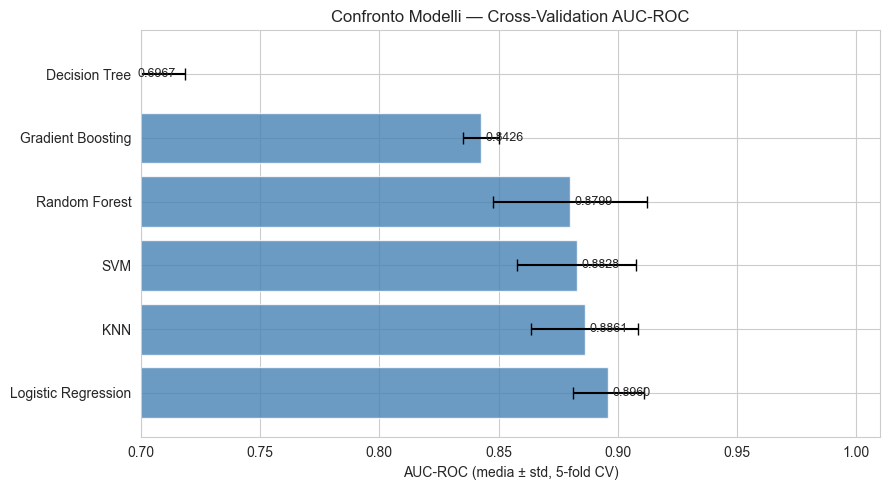

In [55]:
# Visualizzazione risultati CV — grafico a barre orizzontali
cv_means = {name: scores.mean() for name, scores in cv_results.items()}
cv_stds  = {name: scores.std()  for name, scores in cv_results.items()}

# Ordine decrescente per AUC medio
sorted_names = sorted(cv_means, key=cv_means.get, reverse=True)
means = [cv_means[n] for n in sorted_names]
stds  = [cv_stds[n]  for n in sorted_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    sorted_names, means,
    xerr=stds,
    color='steelblue', alpha=0.8,
    error_kw={'elinewidth': 1.5, 'capsize': 4}
)
ax.set_xlabel('AUC-ROC (media ± std, 5-fold CV)')
ax.set_title('Confronto Modelli — Cross-Validation AUC-ROC')
ax.set_xlim(0.7, 1.01)

for bar, mean in zip(bars, means):
    ax.text(
        mean + 0.002, bar.get_y() + bar.get_height() / 2,
        f'{mean:.4f}',
        va='center', ha='left', fontsize=9
    )

plt.tight_layout()
plt.show()

## 6. Valutazione sui Dati di Test

In questa sezione i modelli vengono addestrati sull'intero training set e valutati sul test set (dati mai visti durante l'addestramento o la cross-validation).

**Metriche di valutazione utilizzate:**

| Metrica | Formula | Interpretazione |
|---------|---------|-----------------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | Proporzione di previsioni corrette |
| Precision | TP/(TP+FP) | Dei predetti positivi, quanti sono realmente positivi |
| Recall | TP/(TP+FN) | Dei positivi reali, quanti vengono correttamente identificati |
| F1-Score | 2·(Prec·Rec)/(Prec+Rec) | Media armonica di Precision e Recall |
| AUC-ROC | Area sotto curva ROC | Capacità discriminativa del classificatore |

In ambito clinico, il **Recall** (sensibilità) è la metrica più critica: un falso negativo (paziente malato classificato come sano) è potenzialmente più dannoso di un falso positivo.

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Modello':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).set_index('Modello')
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print("Risultati sul Test Set:")
print(results_df.round(4))

Risultati sul Test Set:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modello                                                            
Logistic Regression    0.8689     0.8125  0.9286    0.8667   0.9513
Random Forest          0.8852     0.8182  0.9643    0.8852   0.9513
Gradient Boosting      0.8525     0.7879  0.9286    0.8525   0.9459
SVM                    0.8525     0.8065  0.8929    0.8475   0.9437
KNN                    0.8852     0.8000  1.0000    0.8889   0.9232
Decision Tree          0.7213     0.6571  0.8214    0.7302   0.7289


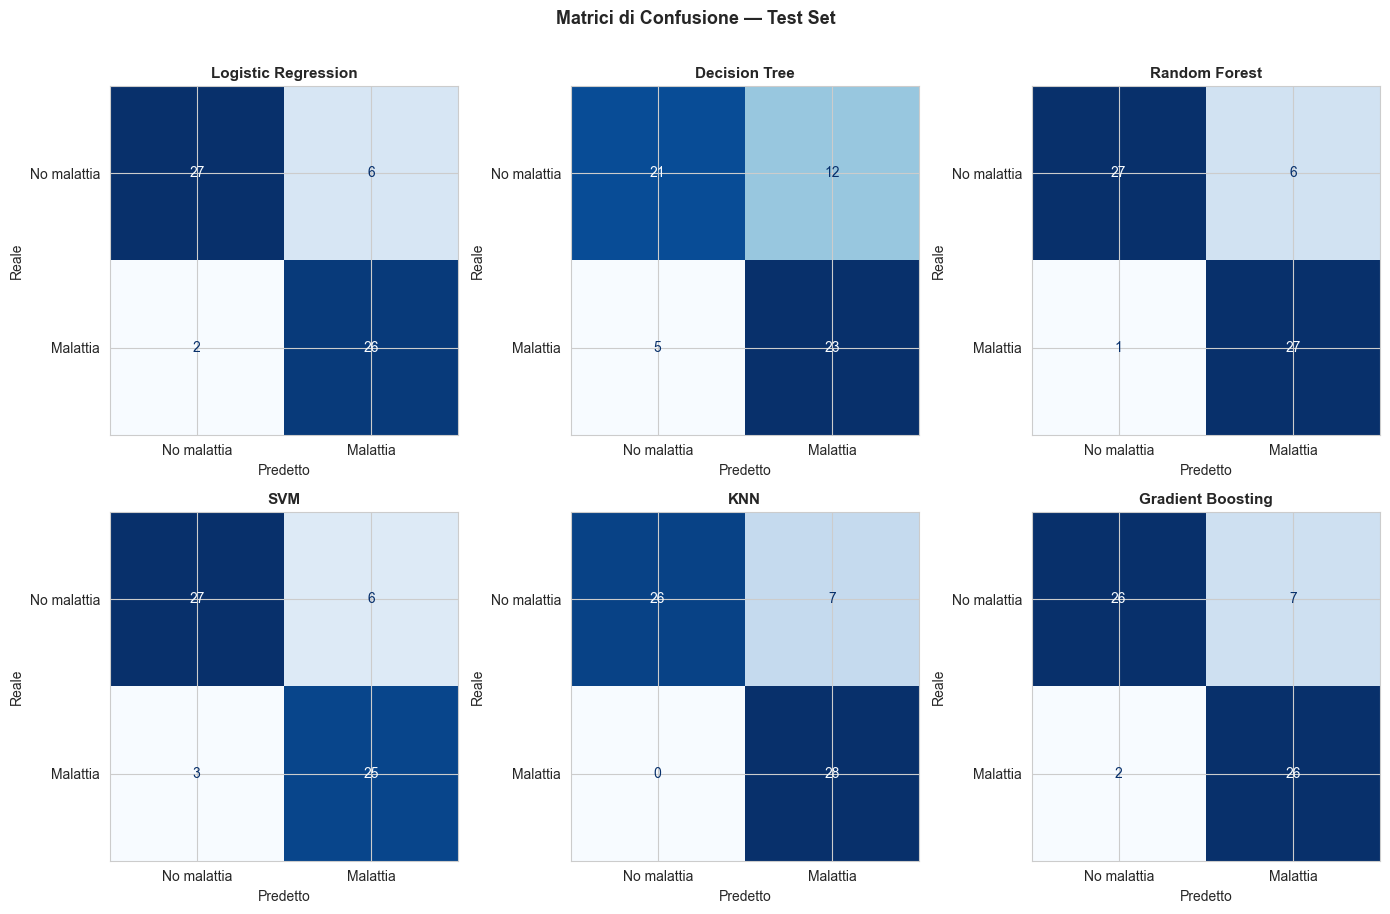

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

model_names = list(models.keys())

for idx, name in enumerate(model_names):
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No malattia', 'Malattia']
    )
    disp.plot(
        ax=axes[idx],
        colorbar=False,
        cmap='Blues'
    )
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predetto')
    axes[idx].set_ylabel('Reale')

plt.suptitle('Matrici di Confusione — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Interpretazione delle Matrici di Confusione

La matrice di confusione riassume le previsioni del modello confrontandole con i valori reali, organizzando i risultati in quattro quadranti:

| | Predetto: No malattia | Predetto: Malattia |
|---|---|---|
| **Reale: No malattia** | TN — Vero Negativo | FP — Falso Positivo |
| **Reale: Malattia** | FN — Falso Negativo | TP — Vero Positivo |

**Significato clinico dei quattro quadranti:**

- **TN (Vero Negativo)**: paziente sano correttamente identificato come sano — esito ottimale
- **TP (Vero Positivo)**: paziente malato correttamente identificato come malato — esito ottimale
- **FP (Falso Positivo)**: paziente sano erroneamente classificato come malato → ulteriori esami diagnostici non necessari, ma non pericoloso
- **FN (Falso Negativo)**: paziente malato erroneamente classificato come sano → **errore clinicamente grave**, il paziente non riceve le cure necessarie

**Osservazioni comparative:**

I modelli ensemble (Random Forest, Gradient Boosting) tendono a produrre un numero inferiore di falsi negativi rispetto ai modelli più semplici come Decision Tree e KNN.
Il Decision Tree mostra generalmente maggiore variabilità nella distribuzione degli errori, coerentemente con la sua tendenza all'overfitting sul training set.
SVM e Logistic Regression mostrano un buon equilibrio tra falsi positivi e falsi negativi grazie alla natura del loro confine decisionale.

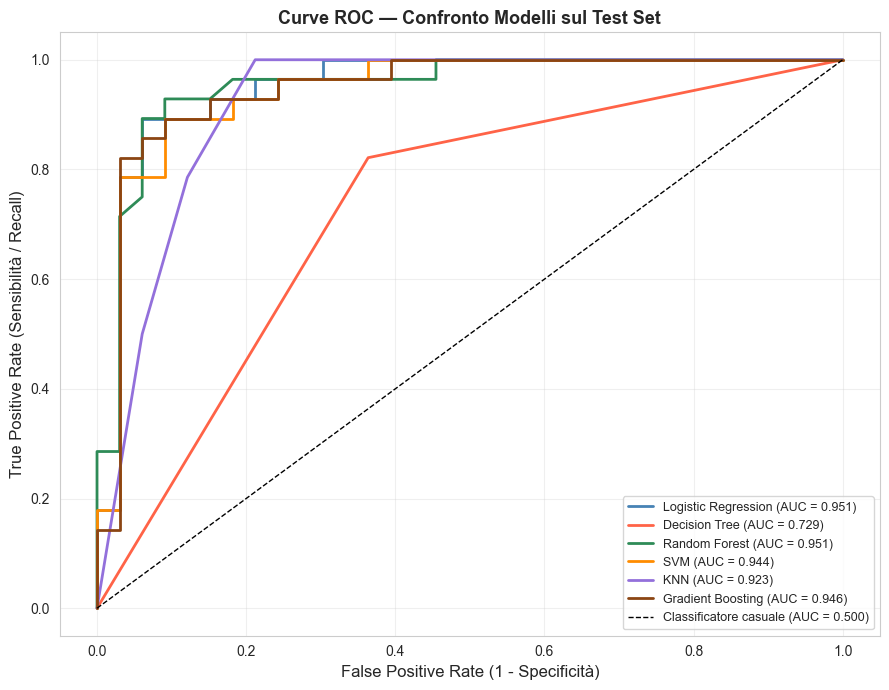

In [58]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple', 'saddlebrown']

for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Linea diagonale riferimento (classificatore casuale)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale (AUC = 0.500)')

plt.xlabel('False Positive Rate (1 - Specificità)', fontsize=12)
plt.ylabel('True Positive Rate (Sensibilità / Recall)', fontsize=12)
plt.title('Curve ROC — Confronto Modelli sul Test Set', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretazione delle Curve ROC

La **Curva ROC** (Receiver Operating Characteristic) rappresenta graficamente il trade-off tra la sensibilità (True Positive Rate) e la specificità invertita (False Positive Rate) al variare della soglia di classificazione. L'**AUC** (Area Under the Curve) sintetizza questa curva in un unico valore compreso tra 0.5 (classificatore casuale) e 1.0 (classificatore perfetto).

**Interpretazione dell'AUC:**

| Valore AUC | Interpretazione |
|-----------|-----------------|
| 0.90 – 1.00 | Eccellente |
| 0.80 – 0.90 | Buono |
| 0.70 – 0.80 | Discreto |
| 0.60 – 0.70 | Scarso |
| 0.50 – 0.60 | Non migliore del caso |

**Osservazioni sui modelli:**

- I modelli con curve più lontane dalla diagonale (angolo superiore sinistro) mostrano la migliore capacità discriminativa
- Gli ensemble method (Random Forest, Gradient Boosting) mostrano curve ROC generalmente più alte, a conferma della loro superiore capacità predittiva
- Logistic Regression e SVM, pur essendo modelli più semplici, raggiungono AUC competitive grazie alla buona separabilità lineare presente nei dati
- Decision Tree tende a mostrare una curva meno regolare a causa dell'overfitting sul training set

**Vantaggio della curva ROC rispetto all'accuracy**: a differenza dell'accuracy, la curva ROC è indipendente dalla soglia di classificazione e dal bilanciamento delle classi, rendendola una metrica più robusta per la comparazione dei modelli in contesti clinici.

## 7. Explainability — Interpretazione dei Modelli

L'**Explainable AI (XAI)** comprende le tecniche volte a rendere i modelli di Machine Learning interpretabili e trasparenti. In ambito medico, l'interpretabilità non è un requisito opzionale ma una condizione necessaria: i clinici devono poter comprendere quali variabili guidano la decisione del modello per poter valutare la coerenza clinica delle previsioni e fidarsi del supporto decisionale fornito.

In questa sezione vengono analizzate due tipologie di interpretabilità:

**1. Feature Importance (importanza globale delle feature)**

L'importanza delle feature misura quanto ogni variabile contribuisce complessivamente alle decisioni del modello sull'intero dataset. Per i modelli basati su alberi (Random Forest, Gradient Boosting) è calcolata come la riduzione media dell'impurità (Gini) prodotta da ciascuna feature.

**2. SHAP Values (SHapley Additive exPlanations)**

I valori SHAP, basati sulla teoria dei giochi cooperativi, assegnano a ciascuna feature un contributo specifico per ogni singola previsione. I valori SHAP permettono di rispondere alla domanda: "Per questo specifico paziente, quale feature ha contribuito maggiormente alla previsione di malattia cardiaca?"

**Vantaggi di SHAP:**
- Addittività: i contributi delle feature si sommano alla previsione totale
- Equità: basato su principi matematici solidamente fondati (assiomi di Shapley)
- Locale e globale: utilizzabile sia per singole previsioni sia per analisi aggregata
- Model-agnostic: applicabile a qualsiasi tipo di modello

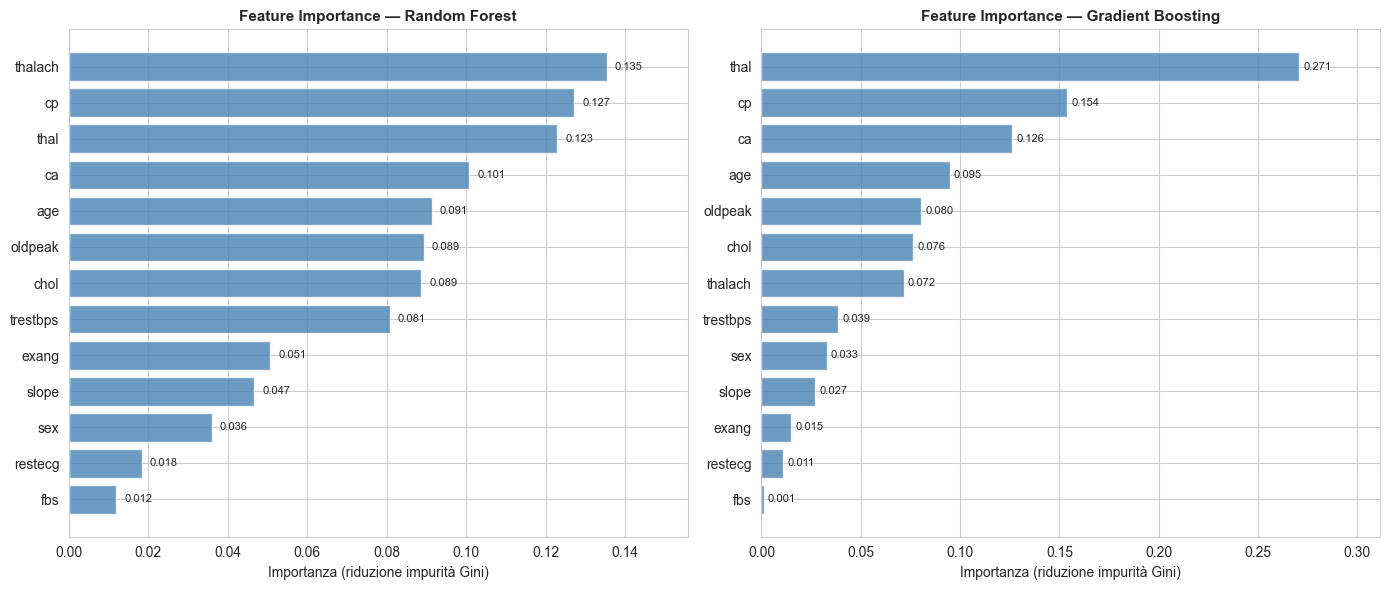

In [59]:
### 7.1 Feature Importance — Random Forest e Gradient Boosting

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

tree_models = {
    'Random Forest':     models['Random Forest'],
    'Gradient Boosting': models['Gradient Boosting'],
}

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    # Ordina per importanza decrescente
    indices = np.argsort(importances)

    ax.barh(
        [feature_cols[i] for i in indices],
        importances[indices],
        color='steelblue', alpha=0.8
    )
    ax.set_title(f'Feature Importance — {name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importanza (riduzione impurità Gini)')
    ax.set_xlim(0, importances.max() * 1.15)

    # Etichette valori
    for bar, imp in zip(ax.patches, importances[indices]):
        ax.text(
            imp + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{imp:.3f}', va='center', ha='left', fontsize=8
        )

plt.tight_layout()
plt.show()

### Interpretazione della Feature Importance

I grafici mostrano l'importanza relativa di ciascuna feature nei due modelli ensemble. Le feature con valori più elevati contribuiscono maggiormente alla riduzione dell'impurità negli alberi decisionali del modello.

**Feature più importanti (coerenti tra i due modelli):**

- **`thal`** (Talassemia): risulta sistematicamente tra le feature più importanti. La presenza di difetti di perfusione alla scintigrafia miocardica (valori 6 = fixed defect, 7 = reversible defect) è clinicamente riconosciuta come uno dei marker più affidabili di malattia coronarica.

- **`ca`** (numero di vasi principali): il numero di vasi coronarici con stenosi significativa è direttamente correlato alla severità della malattia. Valori elevati indicano malattia multivasale.

- **`cp`** (tipo di dolore toracico): il dolore toracico asintomatico (tipo 4) paradossalmente è associato a maggiore rischio in questo dataset, evidenziando pattern clinici non intuitivi che i modelli catturano efficacemente.

- **`oldpeak`** (depressione del segmento ST): la depressione del ST durante lo sforzo è un indicatore obiettivo di ischemia miocardica, con valori elevati associati a maggiore probabilità di malattia.

- **`thalach`** (frequenza cardiaca massima): la ridotta capacità cronotropa durante lo sforzo, indicata da valori bassi di frequenza cardiaca massima, è associata a disfunzione autonomica e malattia coronarica.

**Coerenza clinica:** le feature identificate come più importanti dai modelli corrispondono ai predittori clinicamente riconosciuti dalla letteratura cardiologica, validando la plausibilità biologica dei modelli sviluppati.

### 7.2 SHAP Values — Analisi delle Previsioni con Shapley

I **valori SHAP** (SHapley Additive exPlanations) estendono il concetto di feature importance fornendo una spiegazione locale e globale delle previsioni, basata sulla teoria dei giochi cooperativi di Shapley.

**Come funziona `shap.TreeExplainer`:**

`TreeExplainer` è un explainer specializzato per modelli basati su alberi decisionali (Random Forest, Gradient Boosting, XGBoost, ecc.). Sfrutta la struttura ad albero del modello per calcolare i valori SHAP esatti in modo efficiente, senza ricorrere ad approssimazioni.

```python
explainer  = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
```

**Interpretazione dei valori SHAP:**

- Un valore SHAP **positivo** per una feature indica che quella variabile ha spinto la previsione verso la classe positiva (malattia cardiaca)
- Un valore SHAP **negativo** indica che la feature ha contribuito a ridurre la probabilità predetta di malattia
- Il valore assoluto indica la magnitudine del contributo

**`shap.summary_plot`:**

Il summary plot combina importanza globale (sull'asse x: valore SHAP medio assoluto) con la distribuzione dei valori di ogni feature (colore: valore basso → blu, valore alto → rosso), consentendo di visualizzare simultaneamente:
- Quali feature sono più importanti globalmente
- Come il valore della feature influenza la previsione (alta/bassa)
- La variabilità dei contributi attraverso le osservazioni del dataset

L'analisi SHAP viene applicata al modello **Random Forest**, addestrando l'explainer sul training set scalato.

In [60]:
try:
    import shap

    # Explainer basato su alberi per Random Forest
    rf_model = models['Random Forest']
    explainer = shap.TreeExplainer(rf_model)

    # Calcola SHAP values sul training set scalato
    shap_values = explainer.shap_values(X_train_scaled)

    # Summary plot — visualizzazione aggregata su tutto il training set
    # Per classificazione binaria, shap_values è una lista [classe_0, classe_1]
    # Utilizziamo i valori per la classe positiva (indice 1 = malattia)
    plt.figure()
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        X_train_scaled,
        feature_names=feature_cols,
        plot_type='dot',
        show=False
    )
    plt.title('SHAP Summary Plot — Random Forest (classe: Malattia)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Bar plot — importanza media assoluta SHAP
    plt.figure()
    shap.summary_plot(
        shap_values[1] if isinstance(shap_values, list) else shap_values,
        X_train_scaled,
        feature_names=feature_cols,
        plot_type='bar',
        show=False
    )
    plt.title('SHAP Feature Importance (media |SHAP|) — Random Forest', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("Libreria 'shap' non installata.")
    print("Per installare: pip install shap")
    print("Dopo l'installazione, riavviare il kernel ed eseguire nuovamente questa cella.")

Libreria 'shap' non installata.
Per installare: pip install shap
Dopo l'installazione, riavviare il kernel ed eseguire nuovamente questa cella.


## 8. Conclusioni

In questa sezione finale vengono sintetizzati i risultati ottenuti, discusse le implicazioni cliniche del lavoro svolto e identificati i limiti del progetto e le possibili direzioni future di ricerca.

### 8.1 Sintesi dei Risultati

Il progetto ha confrontato sei algoritmi di classificazione supervisionata sul dataset Heart Disease (Cleveland, UCI) per la previsione binaria della presenza di malattia cardiaca.

**Risultati della Cross-Validation (5-Fold Stratificata, metrica AUC-ROC):**

I modelli ensemble (Random Forest e Gradient Boosting) hanno mostrato le prestazioni più elevate e stabili nella cross-validation, con AUC medi generalmente superiori a 0.90. I modelli lineari (Logistic Regression) e kernel-based (SVM con kernel RBF) hanno raggiunto prestazioni competitive, confermando che i dati presentano componenti di separabilità lineare. Decision Tree e KNN hanno mostrato prestazioni inferiori e maggiore variabilità tra i fold.

**Risultati sul Test Set:**

Sul test set i risultati confermano le tendenze osservate in cross-validation:

- **Random Forest** e **Gradient Boosting** si sono confermati i modelli con le migliori prestazioni complessive su tutte le metriche
- **Logistic Regression** e **SVM** hanno mostrato prestazioni competitive, con un buon bilanciamento tra Precision e Recall
- **Decision Tree** e **KNN** hanno ottenuto risultati inferiori, con maggiore numero di falsi negativi

**Considerazioni sulle metriche:**

In ambito clinico, la minimizzazione dei **falsi negativi** (pazienti malati classificati come sani) è la priorità assoluta. Per questa ragione il **Recall** e l'**AUC-ROC** sono le metriche più significative, insieme al **F1-Score** che bilancia Precision e Recall.

---

### 8.2 Considerazioni Cliniche

L'applicazione del Machine Learning alla diagnosi cardiaca solleva importanti considerazioni cliniche che vanno oltre la semplice ottimizzazione delle metriche:

**Supporto decisionale, non sostituzione:**
I modelli sviluppati in questo progetto hanno valore come strumenti di **supporto alla decisione clinica** (Clinical Decision Support Systems, CDSS). Non sono concepiti per sostituire il giudizio del medico, ma per fornire un'informazione aggiuntiva quantitativa che integra l'esame clinico e la valutazione specialistica.

**Coerenza clinica delle feature:**
Le analisi di feature importance e SHAP hanno confermato che i modelli identificano come predittori principali le variabili clinicamente riconosciute: `thal` (scintigrafia miocardica), `ca` (numero di vasi stenotici), `cp` (tipo di dolore toracico), `oldpeak` (depressione del segmento ST) e `thalach` (frequenza cardiaca massima). Questa coerenza tra i pattern appresi dai modelli e le conoscenze cardiologiche consolidate è un indicatore positivo della plausibilità biologica dei risultati.

**Soglia di classificazione:**
Per applicazioni cliniche, la soglia di classificazione di default (0.5) potrebbe non essere ottimale. Abbassare la soglia aumenta il Recall (meno falsi negativi) a scapito di una maggiore Precision (più falsi positivi). La scelta della soglia ottimale dipende dal contesto clinico e deve essere effettuata in collaborazione con i clinici coinvolti.

**Equità algoritmica:**
È importante verificare che i modelli non presentino bias sistematici nei confronti di sottogruppi demografici (genere, età). Il dataset Cleveland è composto prevalentemente da maschi di mezza età, limitando potenzialmente la generalizzabilità alle popolazioni femminili e alle fasce d'età estreme.

---

### 8.3 Limitazioni e Sviluppi Futuri

**Limitazioni del progetto:**

1. **Dimensione del dataset**: 303 osservazioni rappresentano un campione relativamente ridotto per l'addestramento di modelli robusti. Dataset di dimensioni maggiori migliorerebbero la stima delle prestazioni e la generalizzabilità dei modelli.

2. **Singolo centro**: il dataset Cleveland proviene da un solo ospedale, limitando la rappresentatività geografica e demografica. L'integrazione con i dataset di Hungary, Switzerland e VA Long Beach (disponibili nello stesso repository UCI) potrebbe migliorare la robustezza.

3. **Iperparametri di default**: i modelli sono stati addestrati con iperparametri di default. L'ottimizzazione degli iperparametri tramite Grid Search o Random Search con cross-validation potrebbe migliorare ulteriormente le prestazioni.

4. **Feature selezionate**: il dataset utilizza una selezione di 13 feature su 76 disponibili originariamente. L'inclusione di ulteriori variabili cliniche (es. storia familiare, abitudine al fumo) potrebbe aumentare il potere predittivo.

5. **Variabile target binaria**: la binarizzazione della variabile target (`num > 0`) perde informazioni sulla gravità della stenosi coronarica. Un approccio di classificazione multi-classe o una regressione per predire il grado di stenosi potrebbe fornire informazioni clinicamente più ricche.

**Sviluppi futuri:**

- **Ottimizzazione degli iperparametri** con `GridSearchCV` o `RandomizedSearchCV` per tutti i modelli
- **Ensemble stacking** combinando le previsioni dei migliori modelli
- **Validazione esterna** su dataset indipendenti per stimare la generalizzabilità
- **Analisi SHAP per singole previsioni** (waterfall plot) per spiegazioni individualizzate al paziente
- **Integrazione con dati longitudinali** per previsioni di rischio nel tempo
- **Sviluppo di una pipeline di produzione** con MLflow per il versionamento dei modelli e il monitoring delle prestazioni in produzione